In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import geopandas as gpd

import matplotlib.pyplot as plt

from drawarrow import ax_arrow
from highlight_text import ax_text


## Load crop insurance data

I am using [state / county / crop summary of business](https://www.rma.usda.gov/tools-reports/summary-of-business/state-county-crop-summary-business) data from 1948 - 2026.

In [2]:
CROP = 'corn'
PROJECT_ROOT = Path('.').resolve().parent
INPUT_DIR = PROJECT_ROOT / 'data' / 'processed'

df = pd.read_parquet(f'{INPUT_DIR}/usda_crop_insurance_1948_2026.parquet')
df = df.query(" commodity_name.str.contains(@CROP) ").reset_index(drop=True)
assert(df.commodity_year.min() == 1948 and df.commodity_year.max() == 2026)

df


,commodity_year,state,fips,county_name,commodity_code,commodity_name,policies_sold,policies_premium,policies_indemnified,units_premium,...,insurance_code,insurance_name,coverage_category,delivery_type,coverage_level,quantity_type,endorsed_acres,state_private_subsidy,additional_subsidy,efa_premium_discount
0,1948,IA,19021,BUENA VISTA,0041,corn,1244,1244,0,1481.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1948,IA,19067,FLOYD,0041,corn,393,393,0,450.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1948,IA,19121,MADISON,0041,corn,952,950,0,1173.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1948,IA,19143,OSCEOLA,0041,corn,289,289,0,311.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1948,IA,19169,STORY,0041,corn,372,372,0,435.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
922950,2026,WY,56031,Platte,0041,corn,3,0,0,0.0,...,01,YP,C,RCAT,.5000,Acres,0.0,0.0,0.0,0.0
922951,2026,WY,56043,Washakie,0041,corn,1,0,0,0.0,...,01,YP,A,RBUP,.5000,Acres,0.0,0.0,0.0,0.0
922952,2026,WY,56043,Washakie,0041,corn,2,0,0,0.0,...,01,YP,A,RBUP,.6500,Acres,0.0,0.0,0.0,0.0
922953,2026,WY,56043,Washakie,0041,corn,2,0,0,0.0,...,01,YP,A,RBUP,.7000,Acres,0.0,0.0,0.0,0.0


In [3]:
# NOTE: we are only filtering the data since 1990 this for stats / figures purposes
df = df.query(" commodity_year >= 1990 ")
df


,commodity_year,state,fips,county_name,commodity_code,commodity_name,policies_sold,policies_premium,policies_indemnified,units_premium,...,insurance_code,insurance_name,coverage_category,delivery_type,coverage_level,quantity_type,endorsed_acres,state_private_subsidy,additional_subsidy,efa_premium_discount
38338,1990,AL,01003,Baldwin,0041,corn,4,0,0,0.0,...,90,APH,E,RBUP,.0000,Acres,0.0,0.0,0.0,0.0
38339,1990,AL,01003,Baldwin,0041,corn,3,3,0,3.0,...,90,APH,E,FBUP,.5000,Acres,0.0,0.0,0.0,0.0
38340,1990,AL,01003,Baldwin,0041,corn,1,1,0,1.0,...,90,APH,E,RBUP,.5000,Acres,0.0,0.0,0.0,0.0
38341,1990,AL,01003,Baldwin,0041,corn,7,7,3,12.0,...,90,APH,E,RBUP,.6500,Acres,0.0,0.0,0.0,0.0
38342,1990,AL,01003,Baldwin,0041,corn,7,7,0,8.0,...,90,APH,E,FBUP,.6500,Acres,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
922950,2026,WY,56031,Platte,0041,corn,3,0,0,0.0,...,01,YP,C,RCAT,.5000,Acres,0.0,0.0,0.0,0.0
922951,2026,WY,56043,Washakie,0041,corn,1,0,0,0.0,...,01,YP,A,RBUP,.5000,Acres,0.0,0.0,0.0,0.0
922952,2026,WY,56043,Washakie,0041,corn,2,0,0,0.0,...,01,YP,A,RBUP,.6500,Acres,0.0,0.0,0.0,0.0
922953,2026,WY,56043,Washakie,0041,corn,2,0,0,0.0,...,01,YP,A,RBUP,.7000,Acres,0.0,0.0,0.0,0.0


In [4]:
print('Commodity names:')
print(f'{df.commodity_name.values.unique().tolist()}')
print()

print('Commodity codes:')
print(f'{df.commodity_code.values.unique().tolist()}')
print()

print(f'States growing {CROP}:')
print(f'{sorted(df.state.values.unique().tolist())}')
print()

print('Insurance plans:')
print(f'{sorted(df.insurance_name.values.unique().fillna('').astype('str').tolist())}')
print()

print('Insurance codes:')
print(f'{sorted(df.insurance_code.values.unique().fillna('').astype('str').tolist())}')
print()


Commodity names:
['corn', 'sweet corn', 'fresh market sweet corn', 'hybrid corn seed', 'popcorn', 'grp corn', 'revenue coverage corn', 'income protection corn', 'hybrid sweet corn seed', 'hybrid popcorn seed']

Commodity codes:
['0041', '0042', '0044', '0062', '0043', '0141', '0441', '0341', '0093', '0334']

States growing corn:
['AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']

Insurance plans:
['APH', 'ARP', 'ARP - HPE', 'AYP', 'CLIP', 'CRC', 'DO', 'DOL', 'ECO-RP', 'ECO-RPHPE', 'ECO-YP', 'GRIP', 'GRIP-HRO', 'GRIPH', 'GRP', 'HIP-WI', 'IIP', 'IP', 'MCO-RP', 'MCO-RPHPE', 'MCO-YP', 'MP', 'MP-HPO', 'PACE-RP', 'PACE-RPHPE', 'RA', 'RP', 'RPHPE', 'SCO-RP', 'SCO-RPHPE', 'SCO-YP', 'YDO', 'YP']

Insurance codes:
['01', '02', '03', '04', '05', '06', '12', '16', '17',

In [5]:
print(f'{
        df.query(
        "commodity_name == 'grp corn' or \
         commodity_name == 'revenue coverage corn' or \
         commodity_name == 'income protection corn' "
        ).shape[0] / df.shape[0] * 100
    :.2f}%'
)


0.51%


In [6]:
print(df.query(" commodity_name == 'grp corn' ").commodity_code.unique()[0])
print(df.query(" commodity_name == 'revenue coverage corn' ").commodity_code.unique()[0])
print(df.query(" commodity_name == 'income protection corn' ").commodity_code.unique()[0])


0141
0441
0341


The *grp corn*, *revenue protection corn*, and *income coverage corn* values are in the `commodity_name` column are insurance plans. In our case, there are several thousand rows of these policies, but still  make up less than 1% of our dataset.


In [7]:
only_insurance = df.query(" commodity_code in ['0141', '0441', '0341'] ")
assert(only_insurance.endorsed_acres.all() == 0)
only_insurance


,commodity_year,state,fips,county_name,commodity_code,commodity_name,policies_sold,policies_premium,policies_indemnified,units_premium,...,insurance_code,insurance_name,coverage_category,delivery_type,coverage_level,quantity_type,endorsed_acres,state_private_subsidy,additional_subsidy,efa_premium_discount
62169,1994,IA,19003,Adams,0141,grp corn,1,0,0,0.0,...,12,GRP,E,RBUP,.0000,Acres,0.0,0.0,0.0,0.0
62170,1994,IA,19003,Adams,0141,grp corn,7,7,0,7.0,...,12,GRP,E,RBUP,.6500,Acres,0.0,0.0,0.0,0.0
62171,1994,IA,19003,Adams,0141,grp corn,2,2,0,2.0,...,12,GRP,E,RBUP,.8000,Acres,0.0,0.0,0.0,0.0
62178,1994,IA,19005,Allamakee,0141,grp corn,1,0,0,0.0,...,12,GRP,E,RBUP,.0000,Acres,0.0,0.0,0.0,0.0
62179,1994,IA,19005,Allamakee,0141,grp corn,3,3,0,3.0,...,12,GRP,E,RBUP,.6500,Acres,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107393,1996,WI,55141,Wood,0141,grp corn,1,1,1,1.0,...,12,GRP,A,RBUP,.9000,Acres,0.0,0.0,0.0,0.0
107394,1996,WI,55141,Wood,0141,grp corn,2,0,0,0.0,...,12,GRP,L,RBUP,.0000,Acres,0.0,0.0,0.0,0.0
107395,1996,WI,55141,Wood,0141,grp corn,1,1,0,1.0,...,12,GRP,L,RBUP,.7000,Acres,0.0,0.0,0.0,0.0
107396,1996,WI,55141,Wood,0141,grp corn,3,3,0,3.0,...,12,GRP,L,RBUP,.8000,Acres,0.0,0.0,0.0,0.0


## Load in state and county boundaries from Natural Earth

In [8]:
world_states_url = 'https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_1_states_provinces_lakes.zip'
world_states = gpd.read_file(world_states_url)
states = world_states.query(" adm0_a3 == 'USA' ")
states = states[['name', 'postal', 'geometry']]
states.columns = ['name', 'state', 'geometry']
states = states.query(" state != 'AK' and state != 'DC' and state != 'HI' ")
states = states.sort_values(by='state').reset_index(drop=True)
states


,name,state,geometry
0,Alabama,AL,"MULTIPOLYGON (((-87.41958 30.4796, -87.42683 3..."
1,Arkansas,AR,"POLYGON ((-90.30422 35.00008, -90.30124 34.995..."
2,Arizona,AZ,"POLYGON ((-111.00627 31.32718, -111.06712 31.3..."
3,California,CA,"MULTIPOLYGON (((-114.72428 32.71284, -114.7645..."
4,Colorado,CO,"POLYGON ((-109.04633 40.99983, -108.88932 40.9..."
5,Connecticut,CT,"POLYGON ((-73.6417 41.00177, -73.64286 41.0010..."
6,Delaware,DE,"POLYGON ((-75.05809 38.45372, -75.06273 38.457..."
7,Florida,FL,"MULTIPOLYGON (((-87.44734 30.31314, -87.46443 ..."
8,Georgia,GA,"MULTIPOLYGON (((-80.89029 32.03266, -80.88939 ..."
9,Iowa,IA,"POLYGON ((-96.48266 42.51834, -96.48217 42.553..."


In [9]:
counties_url = 'https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_2_counties_lakes.zip'
counties = gpd.read_file(counties_url)

counties = counties[['NAME', 'NAME_ALT', 'REGION', 'FIPS', 'geometry']]
counties.columns = ['name', 'name_alt', 'region', 'fips', 'geometry']

# remove the 'US' value prepended to the fips codes
counties['fips'] = [fips[2:] for fips in counties.fips]

# we want to exclude alaska, d.c., hawaii, puerto rico, and the usa virgin islands here
counties = counties.query(" region != 'AK' and region != 'DC' and region != 'HI' and region != 'PR' and region != 'VI' ")
counties.rename(columns={'region':'state'}, inplace=True)
counties


,name,name_alt,state,fips,geometry
0,Whatcom,Whatcom County,WA,53073,"MULTIPOLYGON (((-122.75302 48.99251, -122.6532..."
1,Okanogan,Okanogan County,WA,53047,"POLYGON ((-120.85196 48.99251, -120.67495 48.9..."
2,Ferry,Ferry County,WA,53019,"POLYGON ((-118.83688 48.99251, -118.69668 48.9..."
3,Stevens,Stevens County,WA,53065,"POLYGON ((-118.21996 48.99251, -118.03723 48.9..."
4,Pend Oreille,Pend Oreille County,WA,53051,"POLYGON ((-117.42951 48.99251, -117.37787 48.9..."
...,...,...,...,...,...
3185,Washakie,Washakie County,WY,56043,"POLYGON ((-108.55055 44.16845, -108.19008 44.1..."
3186,Fremont,Fremont County,WY,56013,"POLYGON ((-107.52291 42.43435, -107.52271 42.2..."
3187,Natrona,Natrona County,WY,56025,"POLYGON ((-106.07584 42.43321, -106.32218 42.4..."
3188,Hot Springs,Hot Springs County,WY,56017,"POLYGON ((-107.59509 43.50139, -107.59512 43.4..."


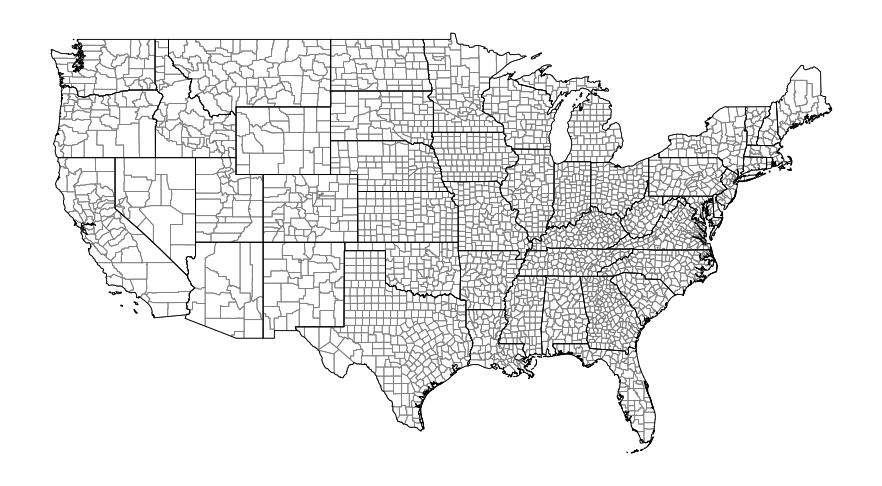

In [10]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

counties.plot(facecolor='none', edgecolor='gray', linewidth=0.5, ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

ax.axis('off')

plt.show()


## Analyzing premiums and subsidies

In [11]:
premiums_subsidies_indemnities = df[['commodity_year', 'total_premium', 'subsidy', 'indemnity']].groupby(by='commodity_year').sum().reset_index(drop=False)
premiums_subsidies_indemnities.head()


,commodity_year,total_premium,subsidy,indemnity
0,1990,189575311.0,47929498.0,100893265.0
1,1991,160233935.0,40931315.0,188552211.0
2,1992,205498913.0,51853916.0,158425769.0
3,1993,190221922.0,48682564.0,617308577.0
4,1994,283130976.0,73969421.0,54108350.0


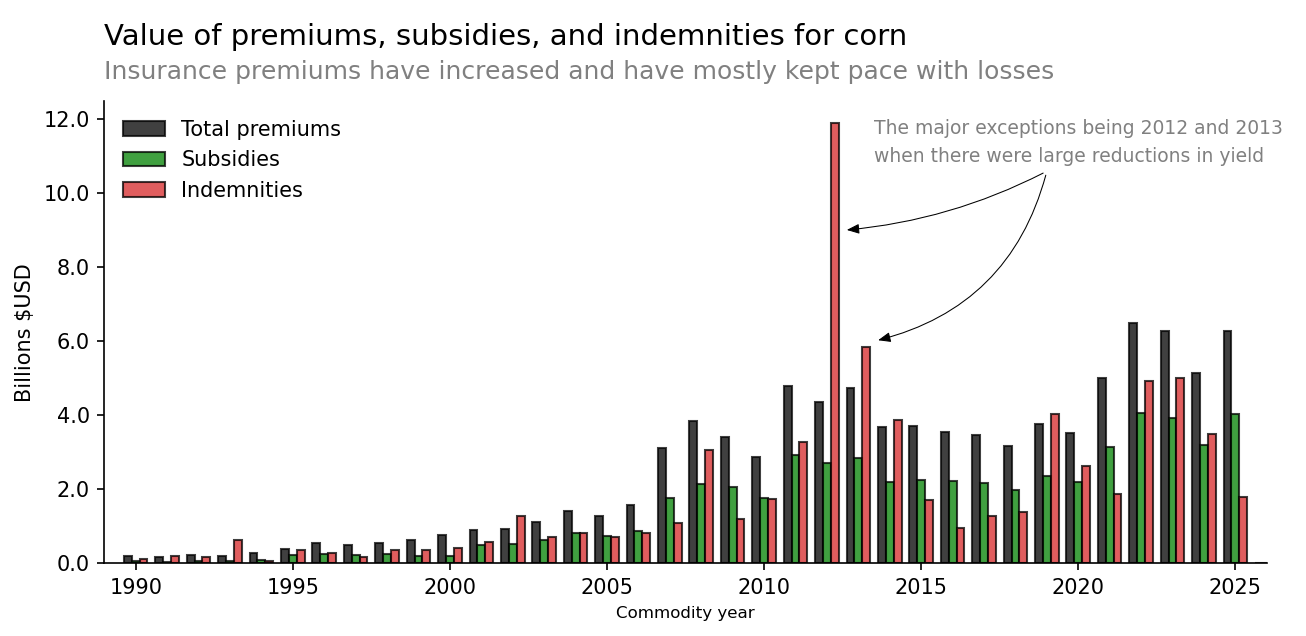

In [12]:
width = 0.25
multiplier = -1
x = premiums_subsidies_indemnities.commodity_year.values

arrow_props = dict(
    color='black', 
    width=0.5, 
    head_width=2, 
    head_length=5,
)

fig, ax = plt.subplots(figsize=(10, 4), dpi=150)

for col, values in premiums_subsidies_indemnities.drop('commodity_year', axis=1).items():

    if col == 'total_premium':
        color = 'black'
        label = 'Total premiums'
    elif col == 'subsidy':
        color = 'green'
        label = 'Subsidies'
    else:
        color = 'tab:red'
        label = 'Indemnities'
    
    offset = width * multiplier
    
    rects = ax.bar(
        x + offset, values, 
        width, 
        color=color,
        edgecolor='black', 
        alpha=0.75,
        label=label,
    )
    
    multiplier += 1

ax.set_xlabel('Commodity year', size=8)

ax.set_xlim([1989, 2026])
ax.set_yticks(ticks=np.arange(0, 12.5e9, 2e9), labels=np.arange(0, 12.5, 2))
ax.set_ylabel('Billions $USD')

ax.legend(loc='upper left', frameon=False)

s = f'Value of premiums, subsidies, and indemnities for {CROP}'
ax_text(x=1989, y=14.6e9, s=s, size=14, ha='left')

s = 'Insurance premiums have increased and have mostly kept pace with losses'
ax_text(x=1989, y=13.6e9, s=s, size=12, color='gray', ha='left')

s = 'The major exceptions being 2012 and 2013\nwhen there were large reductions in yield'
ax_text(x=2013.5, y=12e9, s=s, size=9, color='gray', ha='left')
ax_arrow(tail_position=(2019, 10.6e9), head_position=(2012.5, 9.0e9), radius=0.1, invert=True, **arrow_props)
ax_arrow(tail_position=(2019, 10.6e9), head_position=(2013.5, 6.0e9), radius=0.3, invert=True, **arrow_props)

ax.spines[['top', 'right']].set_visible(False)

plt.show()


The yield for corn has continued to rise since the 90s, but ther have been a few dips, most notably in the 2012/13 growing season. While interannual variation in yield for any crop is normal, according to the USDA ERS, [yield declines seem to have been caused by high temperatures and low precipitation in July](https://www.ers.usda.gov/data-products/charts-of-note/chart-detail?chartId=76002) of that year.

## Indemnities

### By time

In [13]:
val_indemnities_by_year = df[['commodity_year', 'indemnity']].groupby(by='commodity_year').sum().reset_index(drop=False)
val_indemnities_by_year


,commodity_year,indemnity
0,1990,1.008933e+08
1,1991,1.885522e+08
2,1992,1.584258e+08
3,1993,6.173086e+08
4,1994,5.410835e+07
5,1995,3.649542e+08
6,1996,2.692116e+08
7,1997,1.623745e+08
8,1998,3.567517e+08
9,1999,3.672703e+08


In [14]:
val_indemnities_by_state_and_year = df[['state', 'commodity_year', 'indemnity']].groupby(by=['state', 'commodity_year']).sum()
val_indemnities_by_state_and_year = val_indemnities_by_state_and_year.reset_index()
val_indemnities_by_state_and_year


,state,commodity_year,indemnity
0,AL,1990,405634.0
1,AL,1991,325271.0
2,AL,1992,186302.0
3,AL,1993,840227.0
4,AL,1994,89521.0
...,...,...,...
1640,WY,2022,2451395.0
1641,WY,2023,2090427.0
1642,WY,2024,1795417.0
1643,WY,2025,4186135.0


### By state

In [15]:
num_indemnities_by_state = df[['state', 'policies_indemnified']].groupby(by='state').sum()
num_indemnities_by_state = num_indemnities_by_state.sort_values(by='policies_indemnified', ascending=False).reset_index()
num_indemnities_by_state = num_indemnities_by_state.merge(states, on='state', how='left')[['state', 'name', 'policies_indemnified', 'geometry']]
num_indemnities_by_state = gpd.GeoDataFrame(num_indemnities_by_state).set_geometry('geometry')
num_indemnities_by_state = num_indemnities_by_state.query(" policies_indemnified > 0 ")
num_indemnities_by_state


,state,name,policies_indemnified,geometry
0,IA,Iowa,493705,"POLYGON ((-96.48266 42.51834, -96.48217 42.553..."
1,IL,Illinois,444019,"POLYGON ((-89.1237 36.97964, -89.14345 36.9868..."
2,NE,Nebraska,344651,"POLYGON ((-104.05373 40.99983, -104.05292 41.1..."
3,MN,Minnesota,272968,"POLYGON ((-97.22609 48.99267, -97.15538 48.992..."
4,SD,South Dakota,244649,"POLYGON ((-104.05666 45.0001, -104.0393 44.999..."
5,KS,Kansas,222681,"POLYGON ((-102.03957 36.99981, -102.03994 37.0..."
6,IN,Indiana,191937,"POLYGON ((-84.80608 41.69681, -84.80608 41.617..."
7,MO,Missouri,182396,"POLYGON ((-95.31725 40.0001, -95.34421 40.0192..."
8,OH,Ohio,153046,"POLYGON ((-80.52023 41.98446, -80.52023 41.904..."
9,WI,Wisconsin,128416,"MULTIPOLYGON (((-87.80425 42.4918, -87.97829 4..."


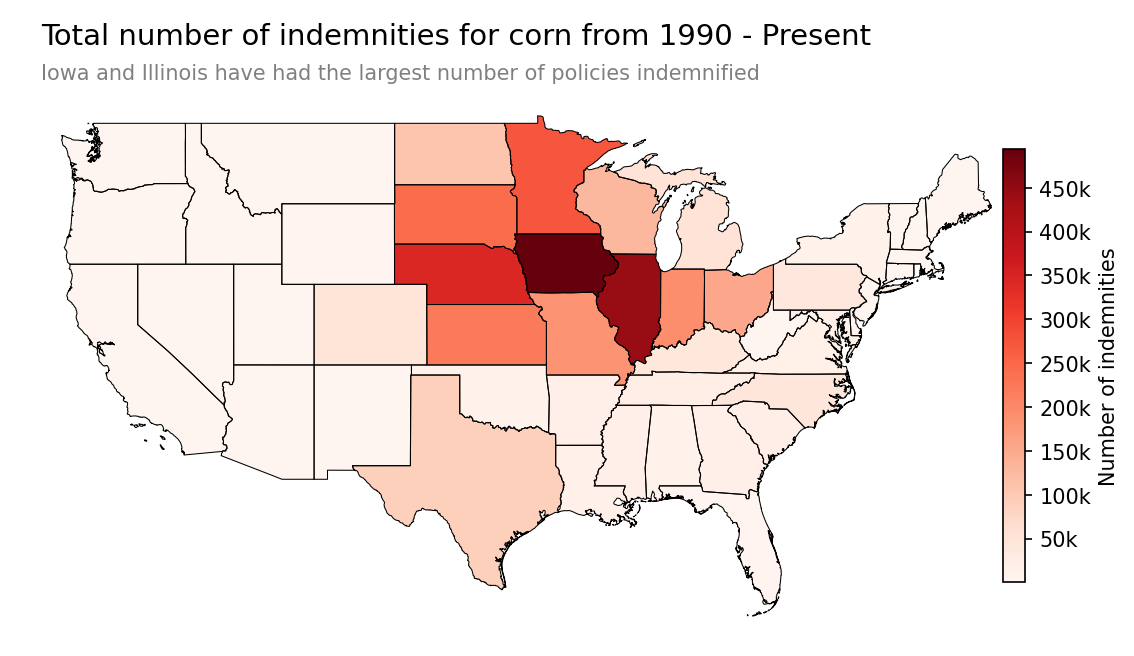

In [16]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

num_indemnities_by_state.plot(column='policies_indemnified', cmap='Reds', ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

vmin = num_indemnities_by_state['policies_indemnified'].min()
vmax = num_indemnities_by_state['policies_indemnified'].max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
mapper = plt.cm.ScalarMappable(cmap='Reds', norm=norm)

cbar = plt.colorbar(mapper, shrink=0.75, ax=ax, pad=-0.03)
cbar.set_ticks(np.arange(50000, 500000, 50000))
cbar.set_ticklabels([str(val)+'k' for val in np.arange(50, 500, 50)])
cbar.set_label('Number of indemnities')

s = f'Total number of indemnities for {CROP} from 1990 - Present'
ax_text(x=-126, y=54, s=s, size=14, color='black', ha='left')

s = 'Iowa and Illinois have had the largest number of policies indemnified'
ax_text(x=-126, y=52, s=s, size=10, color='gray', ha='left')
ax.axis('off')

plt.show()


In [17]:
val_indemnities_by_state = df[['state', 'indemnity']].groupby(by='state').sum()
val_indemnities_by_state = val_indemnities_by_state.sort_values(by='indemnity', ascending=False).reset_index()
val_indemnities_by_state = val_indemnities_by_state.merge(states, on='state', how='left')[['state', 'name', 'indemnity', 'geometry']]
val_indemnities_by_state = gpd.GeoDataFrame(val_indemnities_by_state).set_geometry('geometry')
val_indemnities_by_state = val_indemnities_by_state.query(" indemnity > 0 ")
val_indemnities_by_state


,state,name,indemnity,geometry
0,IA,Iowa,9.713729e+09,"POLYGON ((-96.48266 42.51834, -96.48217 42.553..."
1,IL,Illinois,7.655818e+09,"POLYGON ((-89.1237 36.97964, -89.14345 36.9868..."
2,NE,Nebraska,6.409718e+09,"POLYGON ((-104.05373 40.99983, -104.05292 41.1..."
3,MN,Minnesota,6.270087e+09,"POLYGON ((-97.22609 48.99267, -97.15538 48.992..."
4,SD,South Dakota,6.169477e+09,"POLYGON ((-104.05666 45.0001, -104.0393 44.999..."
5,KS,Kansas,4.802661e+09,"POLYGON ((-102.03957 36.99981, -102.03994 37.0..."
6,ND,North Dakota,3.996277e+09,"POLYGON ((-104.04757 48.99262, -103.96949 48.9..."
7,IN,Indiana,3.745756e+09,"POLYGON ((-84.80608 41.69681, -84.80608 41.617..."
8,MO,Missouri,3.389165e+09,"POLYGON ((-95.31725 40.0001, -95.34421 40.0192..."
9,TX,Texas,2.472068e+09,"MULTIPOLYGON (((-103.31151 29.02604, -103.3099..."


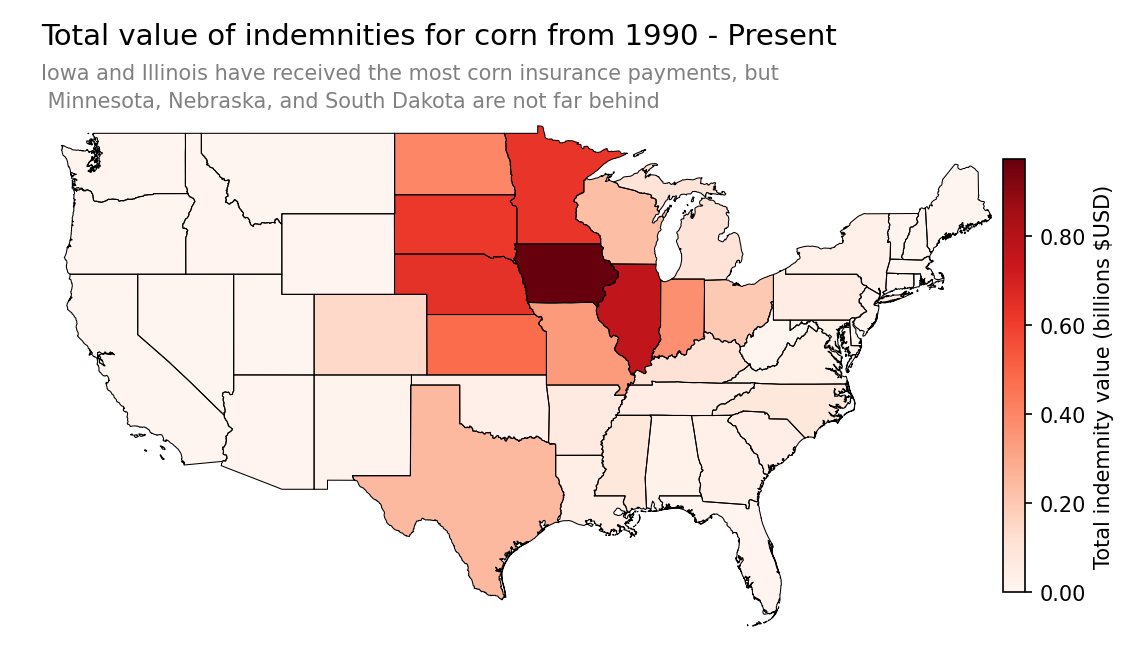

In [18]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

val_indemnities_by_state.plot(column='indemnity', cmap='Reds', ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

vmin = val_indemnities_by_state['indemnity'].min()
vmax = val_indemnities_by_state['indemnity'].max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
mapper = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
cbar = plt.colorbar(mapper, shrink=0.75, ax=ax, pad=-0.03)
cbar.set_ticks(np.arange(0e10, 1e10, 0.2e10))
cbar.set_ticklabels([f'{val:.2f}' for val in np.arange(0, 1, 0.2)])
cbar.set_label('Total indemnity value (billions $USD)', fontsize=10)

s = f'Total value of indemnities for {CROP} from 1990 - Present'
ax_text(x=-126, y=54.5, s=s, size=14, color='black', ha='left')

s = f'Iowa and Illinois have received the most {CROP} insurance payments, but\n Minnesota, Nebraska, and South Dakota are not far behind'
ax_text(x=-126, y=52.5, s=s, size=10, color='gray', ha='left')

ax.axis('off')

plt.show()


### By county

In [19]:
num_indemnities_by_county = df[['fips', 'county_name', 'policies_indemnified']].groupby(by=['fips', 'county_name']).sum()
num_indemnities_by_county = num_indemnities_by_county.sort_values(by='policies_indemnified', ascending=False).reset_index()
num_indemnities_by_county = num_indemnities_by_county.merge(counties, on='fips', how='left')[['state', 'name', 'fips', 'policies_indemnified', 'geometry']]
num_indemnities_by_county = gpd.GeoDataFrame(num_indemnities_by_county).set_geometry('geometry')
num_indemnities_by_county = num_indemnities_by_county.query(" policies_indemnified > 0 ")
num_indemnities_by_county


,state,name,fips,policies_indemnified,geometry
0,IL,Livingston,17105,18460,"POLYGON ((-88.24718 40.99474, -88.24157 40.824..."
1,IL,Iroquois,17075,16932,"POLYGON ((-87.52589 40.73694, -87.52604 40.703..."
2,IL,Champaign,17019,12687,"POLYGON ((-87.93286 40.39953, -87.92902 40.225..."
3,SD,Brown,46013,12499,"POLYGON ((-98.00811 45.94185, -97.97877 45.941..."
4,SD,Hutchinson,46067,11527,"POLYGON ((-97.63749 43.16876, -98.0771 43.1683..."
...,...,...,...,...,...
2152,IN,Brown,18013,1,"POLYGON ((-86.0856 39.34418, -86.08247 39.2500..."
2153,WA,Skagit,53057,1,"MULTIPOLYGON (((-122.38183 48.29682, -122.3858..."
2154,ID,Minidoka,16067,1,"POLYGON ((-113.71554 43.19993, -113.41452 43.1..."
2155,TX,Collingsworth,48087,1,"POLYGON ((-100.00002 35.03133, -99.99992 34.97..."


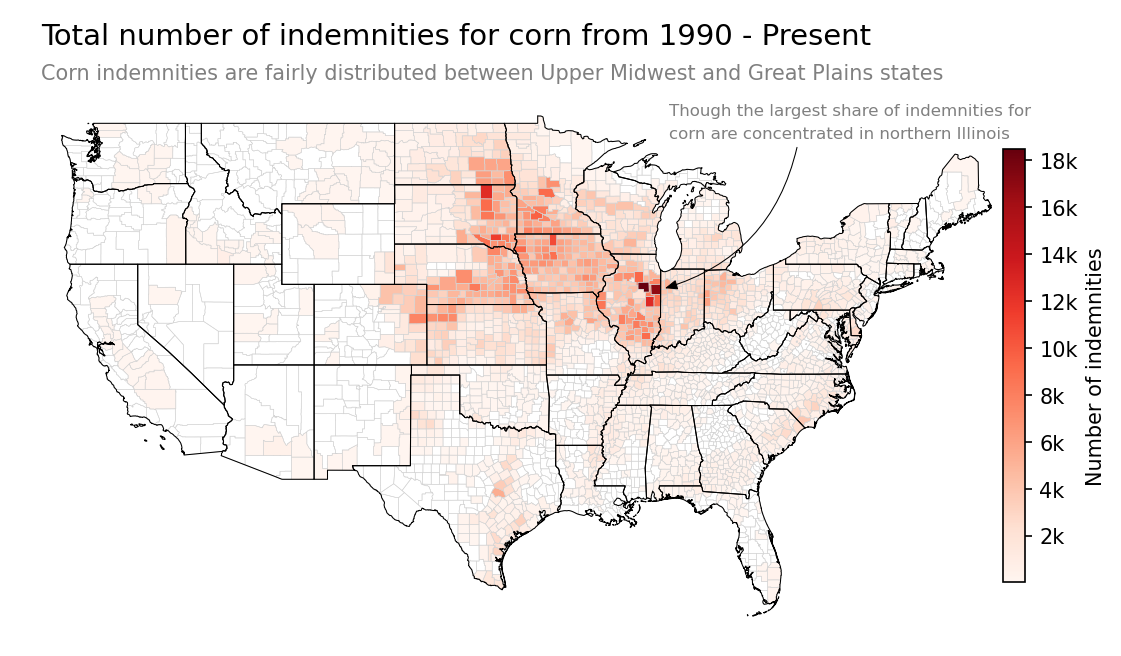

In [20]:
arrow_props = dict(
    color='black', 
    width=0.5, 
    head_width=2, 
    head_length=5,
)

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

num_indemnities_by_county.plot(column='policies_indemnified', cmap='Reds', ax=ax)
counties.plot(facecolor='none', edgecolor='lightgray', linewidth=0.25, ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

vmin = num_indemnities_by_county['policies_indemnified'].min()
vmax = num_indemnities_by_county['policies_indemnified'].max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
mapper = plt.cm.ScalarMappable(cmap='Reds', norm=norm)

cbar = plt.colorbar(mapper, shrink=0.75, ax=ax, pad=-0.03)
cbar.set_ticks(np.arange(2000, 20000, 2000))
cbar.set_ticklabels([str(val)+'k' for val in np.arange(2, 20, 2)])
cbar.set_label('Number of indemnities')

s = f'Total number of indemnities for {CROP} from 1990 - Present'
ax_text(x=-126, y=54, s=s, size=14, color='black', ha='left')

s = f'{CROP.title()} indemnities are fairly distributed between Upper Midwest and Great Plains states'
ax_text(x=-126, y=52, s=s, size=10, color='gray', ha='left')

s = f'Though the largest share of indemnities for\n{CROP} are concentrated in northern Illinois'
ax_text(x=-87, y=50, s=s, size=8, color='gray', ha='left')
ax_arrow(tail_position=(-79, 48), head_position=(-87.5, 40.75), radius=0.3, invert=True, **arrow_props)

ax.axis('off')

plt.show()


In [21]:
val_indemnities_by_county = df[['fips', 'county_name', 'indemnity']].groupby(by=['fips', 'county_name']).sum()
val_indemnities_by_county = val_indemnities_by_county.sort_values(by='indemnity', ascending=False).reset_index()
val_indemnities_by_county = val_indemnities_by_county.merge(counties, on='fips', how='left')[['state', 'name', 'fips', 'indemnity', 'geometry']]
val_indemnities_by_county = gpd.GeoDataFrame(val_indemnities_by_county).set_geometry('geometry')
val_indemnities_by_county = val_indemnities_by_county.query(" indemnity > 0 ")
val_indemnities_by_county


,state,name,fips,indemnity,geometry
0,SD,Brown,46013,552908870.0,"POLYGON ((-98.00811 45.94185, -97.97877 45.941..."
1,KS,Thomas,20193,365417859.0,"POLYGON ((-100.74086 39.56804, -100.7202 39.56..."
2,ND,Dickey,38021,346545313.0,"POLYGON ((-98.00811 45.94185, -98.18705 45.941..."
3,SD,Hutchinson,46067,318828102.0,"POLYGON ((-97.63749 43.16876, -98.0771 43.1683..."
4,ND,Cass,38017,308291216.0,"POLYGON ((-96.8332 47.15061, -96.83591 47.1406..."
...,...,...,...,...,...
2152,MT,Stillwater,30095,147.0,"POLYGON ((-108.83983 45.62311, -109.00731 45.6..."
2153,NY,Delaware,36025,87.0,"POLYGON ((-75.35129 41.99739, -75.36285 41.997..."
2154,NC,Gaston,37071,75.0,"POLYGON ((-81.04474 35.14278, -81.04846 35.146..."
2155,MI,Charlevoix,26029,35.0,"MULTIPOLYGON (((-84.85745 45.1167, -84.97869 4..."


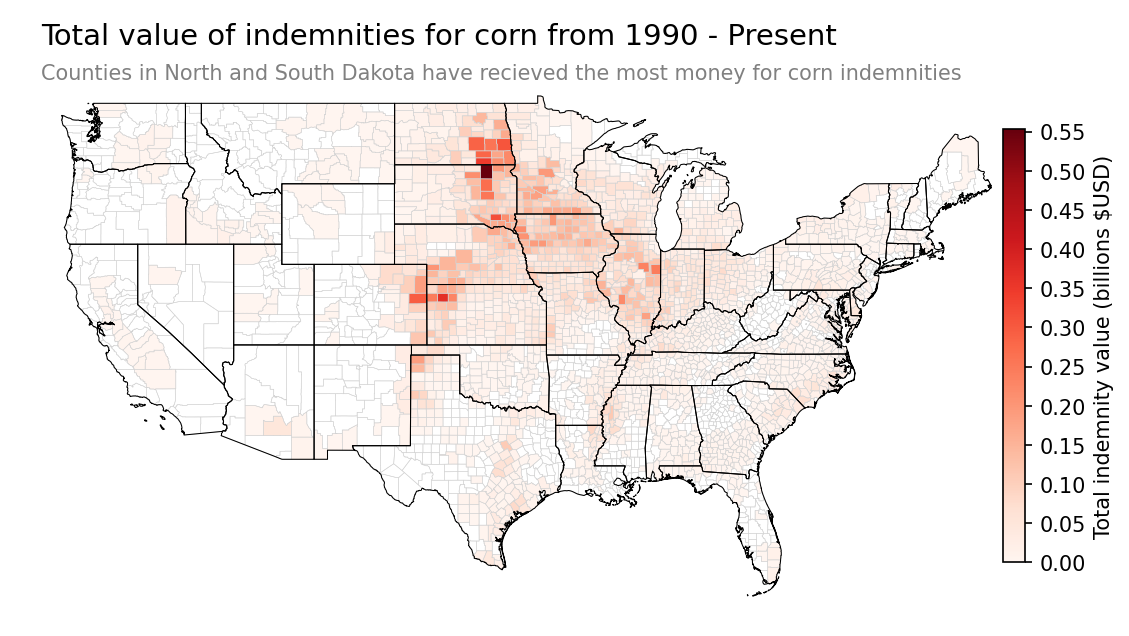

In [22]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

val_indemnities_by_county.plot(column='indemnity', cmap='Reds', ax=ax)
counties.plot(facecolor='none', edgecolor='lightgray', linewidth=0.25, ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

vmin = val_indemnities_by_county['indemnity'].min()
vmax = val_indemnities_by_county['indemnity'].max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
mapper = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
cbar = plt.colorbar(mapper, shrink=0.75, ax=ax, pad=-0.03)
cbar.set_ticks(np.arange(0e9, 0.6e9, 0.05e9))
cbar.set_ticklabels([f'{val:.2f}' for val in np.arange(0.0, 0.6, 0.05)])
cbar.set_label('Total indemnity value (billions $USD)', fontsize=10)

s = f'Total value of indemnities for {CROP} from 1990 - Present'
ax_text(x=-126, y=53, s=s, size=14, color='black', ha='left')

s = f'Counties in North and South Dakota have recieved the most money for {CROP} indemnities'
ax_text(x=-126, y=51, s=s, size=10, color='gray', ha='left')

ax.axis('off')

plt.show()


In [23]:
loss_ratio_by_county = df[['fips', 'county_name', 'loss_ratio']].groupby(by=['fips', 'county_name']).mean()
loss_ratio_by_county = loss_ratio_by_county.sort_values(by='loss_ratio', ascending=False).reset_index()
loss_ratio_by_county = loss_ratio_by_county.merge(counties, on='fips', how='left')[['state', 'name', 'fips', 'loss_ratio', 'geometry']]
loss_ratio_by_county = gpd.GeoDataFrame(loss_ratio_by_county).set_geometry('geometry')
loss_ratio_by_county = loss_ratio_by_county.query(" loss_ratio > 0 ")
loss_ratio_by_county


,state,name,fips,loss_ratio,geometry
0,CA,Sutter,06101,16.088370,"POLYGON ((-121.90862 39.30519, -121.77074 39.3..."
1,OK,Harper,40059,10.475000,"POLYGON ((-99.54111 36.99981, -99.47079 36.999..."
2,OK,Tulsa,40143,8.666667,"POLYGON ((-96.03311 35.85682, -96.02958 35.901..."
3,AZ,Pinal,04021,4.340931,"POLYGON ((-111.03989 33.4661, -110.9747 33.342..."
4,TX,Jones,48253,4.236667,"POLYGON ((-99.61202 32.51465, -99.62957 32.514..."
...,...,...,...,...,...
2151,IL,DuPage,17043,0.010000,"POLYGON ((-88.26287 41.98622, -88.14703 41.988..."
2152,NC,Gaston,37071,0.007500,"POLYGON ((-81.04474 35.14278, -81.04846 35.146..."
2153,ID,Minidoka,16067,0.002182,"POLYGON ((-113.71554 43.19993, -113.41452 43.1..."
2154,MT,Stillwater,30095,0.001803,"POLYGON ((-108.83983 45.62311, -109.00731 45.6..."


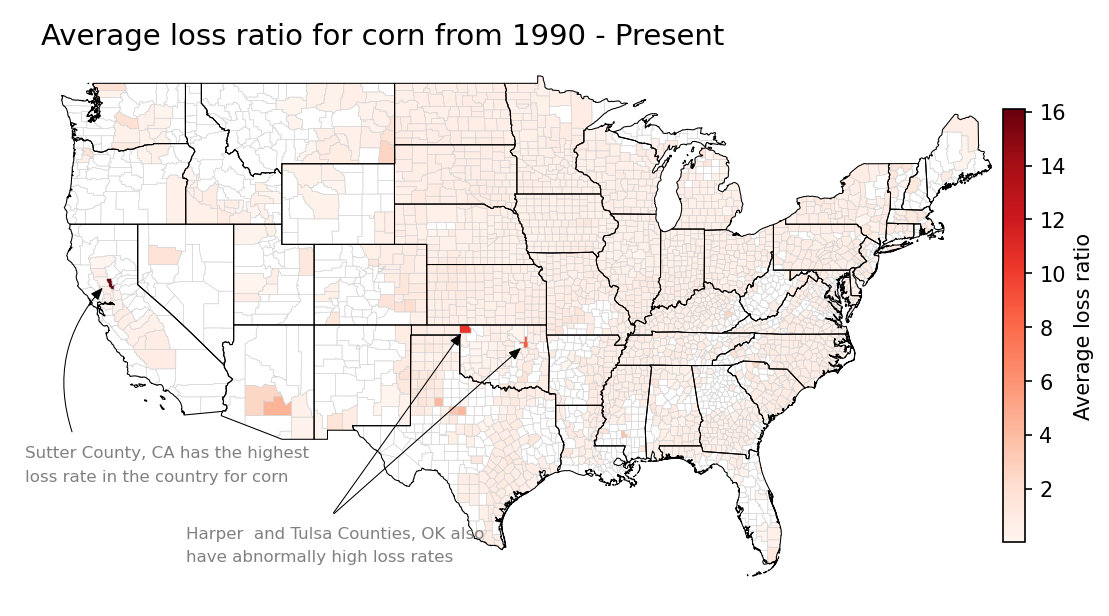

In [24]:
arrow_props = dict(
    color='black', 
    width=0.5, 
    head_width=2, 
    head_length=5,
)

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

loss_ratio_by_county.plot(column='loss_ratio', cmap='Reds', ax=ax)
counties.plot(facecolor='none', edgecolor='lightgray', linewidth=0.25, ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

vmin = loss_ratio_by_county['loss_ratio'].min()
vmax = loss_ratio_by_county['loss_ratio'].max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
mapper = plt.cm.ScalarMappable(cmap='Reds', norm=norm)

cbar = plt.colorbar(mapper, shrink=0.75, ax=ax, pad=-0.03)
cbar.set_label('Average loss ratio')

s = f'Average loss ratio for {CROP} from 1990 - Present'
ax_text(x=-126, y=52, s=s, size=14, color='black', ha='left')

s = f'{loss_ratio_by_county.iloc[0]['name']} County, {loss_ratio_by_county.iloc[0]['state']} has the highest\nloss rate in the country for {CROP}'
ax_text(x=-127, y=31, s=s, size=8, color='gray', ha='left')
ax_arrow(tail_position=(-124, 31.5), head_position=(-122, 39), radius=0.3, invert=True, **arrow_props)

s = f'{loss_ratio_by_county.iloc[1]['name']}  and {loss_ratio_by_county.iloc[2]['name']} Counties, {loss_ratio_by_county.iloc[1]['state']} also\nhave abnormally high loss rates'
ax_text(x=-117, y=27, s=s, size=8, color='gray', ha='left')
ax_arrow(tail_position=(-108, 27.5), head_position=(-99.75, 36.75), **arrow_props)
ax_arrow(tail_position=(-108, 27.5), head_position=(-96, 36), **arrow_props)

ax.axis('off')

plt.show()
